<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/languages/python/mini_projects/web_scraping/experiment_web_scraping_data_extraction_analysis_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1 — Basic Scraping

In [1]:
!pip install requests beautifulsoup4

Simple Example

In [2]:
import requests
from bs4 import BeautifulSoup

url = "https://quotes.toscrape.com"

response = requests.get(url)

soup = BeautifulSoup(
    response.text,
    "html.parser"
)

quotes = soup.find_all("span", class_="text")

for quote in quotes[:5]:
    print(quote.text)

“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
“It is our choices, Harry, that show what we truly are, far more than our abilities.”
“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”
“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”
“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”


STEP 2 — Extract Multiple Fields

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://quotes.toscrape.com"

response = requests.get(url)

soup = BeautifulSoup(
    response.text,
    "html.parser"
)

data = []

for item in soup.find_all("div", class_="quote"):

    quote = item.find(
        "span",
        class_="text"
    ).text

    author = item.find(
        "small",
        class_="author"
    ).text

    data.append([quote, author])

df = pd.DataFrame(
    data,
    columns=["Quote", "Author"]
)

df.head()

,Quote,Author
0,“The world as we have created it is a process ...,Albert Einstein
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling
2,“There are only two ways to live your life. On...,Albert Einstein
3,"“The person, be it gentleman or lady, who has ...",Jane Austen
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe


STEP 3 — Pagination Scraping

In [4]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

all_quotes = []

for page in range(1, 6):

    url = f"https://quotes.toscrape.com/page/{page}/"

    response = requests.get(url)

    soup = BeautifulSoup(
        response.text,
        "html.parser"
    )

    quotes = soup.find_all(
        "div",
        class_="quote"
    )

    for q in quotes:

        quote = q.find(
            "span",
            class_="text"
        ).text

        author = q.find(
            "small",
            class_="author"
        ).text

        all_quotes.append(
            [quote, author]
        )

df = pd.DataFrame(
    all_quotes,
    columns=["Quote", "Author"]
)

print(df.shape)

(50, 2)


STEP 4 — Data Cleaning

In [5]:
df["Quote"] = (
    df["Quote"]
    .str.replace("“", "")
    .str.replace("”", "")
)

df.drop_duplicates(
    inplace=True
)

df.isnull().sum()

,0
Quote,0
Author,0


STEP 5 — Data Manipulation

In [6]:
author_count = (
    df["Author"]
    .value_counts()
)

print(author_count.head())

Author
Albert Einstein    8
J.K. Rowling       6
Marilyn Monroe     6
Dr. Seuss          3
Bob Marley         3
Name: count, dtype: int64


Author Statistics

In [7]:
summary = (
    df.groupby("Author")
      .size()
      .reset_index(name="Quotes")
)

summary.head()

,Author,Quotes
0,Albert Einstein,8
1,Allen Saunders,1
2,André Gide,1
3,Bob Marley,3
4,C.S. Lewis,1


In [9]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=summary)

https://docs.google.com/spreadsheets/d/1U5M9nT2TwEW0XKl8_Y6mMo9n87zToFtekOb7uS3N-kk/edit#gid=0


STEP 6 — Visualization

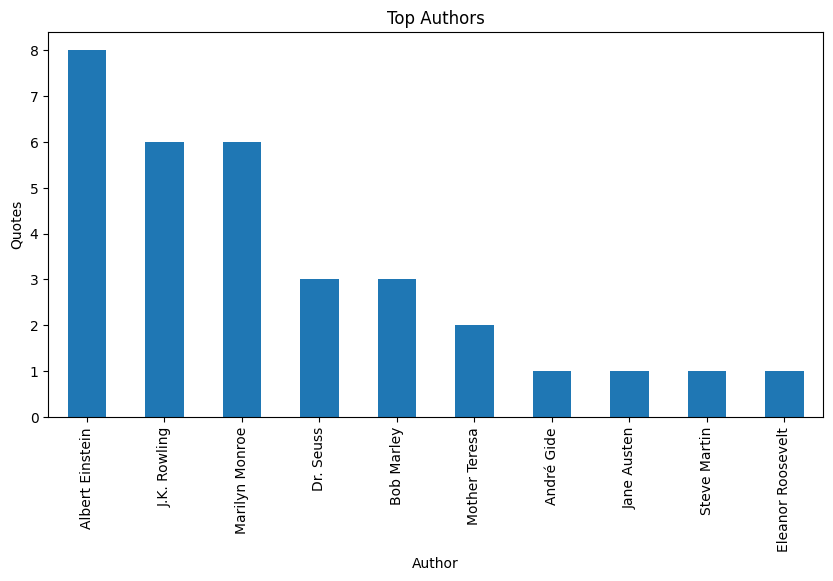

In [10]:
import matplotlib.pyplot as plt

top_authors = (
    df["Author"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

top_authors.plot(
    kind="bar"
)

plt.title(
    "Top Authors"
)

plt.xlabel("Author")
plt.ylabel("Quotes")

plt.show()

STEP 7 — Word Frequency Analysis

In [12]:
from collections import Counter

text = " ".join(
    df["Quote"]
)

words = text.split()

word_freq = Counter(words)

top_words = (
    pd.DataFrame(
        word_freq.items(),
        columns=["Word", "Frequency"]
    )
    .sort_values(
        "Frequency",
        ascending=False
    )
    .head(20)
)

print(top_words)

     Word  Frequency
77    you         53
7      is         43
35     to         37
8       a         31
10     of         22
120   the         20
51    not         19
21   that         17
63    and         17
15     be         15
80      I         15
37   your         14
0     The         13
6      it         13
169   but         13
252   can         13
53     in         12
47     or         10
23   what          9
239   she          9


STEP 8 — Advanced Visualization

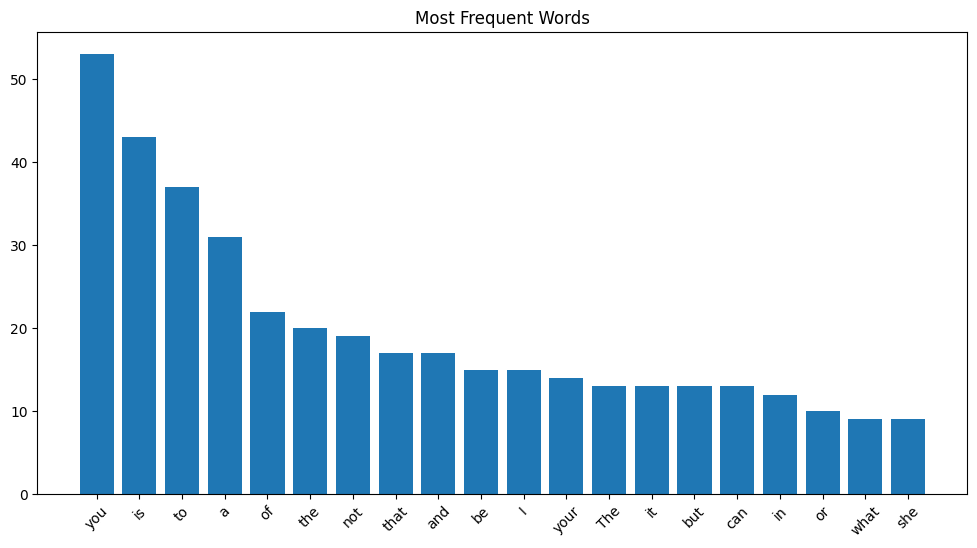

In [13]:
plt.figure(figsize=(12,6))

plt.bar(
    top_words["Word"],
    top_words["Frequency"]
)

plt.xticks(rotation=45)

plt.title(
    "Most Frequent Words"
)

plt.show()

STEP 9 — Concurrent Scraping

In [14]:
from concurrent.futures import ThreadPoolExecutor
import requests

urls = [
    f"https://quotes.toscrape.com/page/{i}/"
    for i in range(1, 11)
]

def fetch(url):

    response = requests.get(url)

    return len(response.text)

with ThreadPoolExecutor(
    max_workers=5
) as executor:

    results = list(
        executor.map(
            fetch,
            urls
        )
    )

print(results)

[11021, 13699, 9987, 10283, 9970, 10374, 10678, 11345, 10980, 9901]


STEP 10 — Production Scraper Class

In [15]:
import requests
import pandas as pd

from bs4 import BeautifulSoup


class QuoteScraper:

    def __init__(self):

        self.base_url = (
            "https://quotes.toscrape.com/page/{}/"
        )

        self.data = []

    def scrape_page(self, page):

        url = self.base_url.format(page)

        response = requests.get(url)

        soup = BeautifulSoup(
            response.text,
            "html.parser"
        )

        quotes = soup.find_all(
            "div",
            class_="quote"
        )

        for q in quotes:

            quote = q.find(
                "span",
                class_="text"
            ).text

            author = q.find(
                "small",
                class_="author"
            ).text

            self.data.append(
                [quote, author]
            )

    def run(self, pages=10):

        for page in range(1, pages + 1):

            self.scrape_page(page)

        return pd.DataFrame(
            self.data,
            columns=[
                "Quote",
                "Author"
            ]
        )


scraper = QuoteScraper()

df = scraper.run()

print(df.head())

                                               Quote           Author
0  “The world as we have created it is a process ...  Albert Einstein
1  “It is our choices, Harry, that show what we t...     J.K. Rowling
2  “There are only two ways to live your life. On...  Albert Einstein
3  “The person, be it gentleman or lady, who has ...      Jane Austen
4  “Imperfection is beauty, madness is genius and...   Marilyn Monroe


STEP 11 — Save Results

In [16]:
df.to_csv(
    "quotes.csv",
    index=False
)

In [17]:
df.to_excel(
    "quotes.xlsx",
    index=False
)

In [18]:
import sqlite3

conn = sqlite3.connect(
    "quotes.db"
)

df.to_sql(
    "quotes",
    conn,
    if_exists="replace",
    index=False
)

conn.close()